### Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_features.csv")
master_df = pd.read_csv("master_dataset.csv")

In [2]:
orders

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,Delivery_Delay_Minutes,Late_Delivery_Flag,Order_size
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,-5.0,0,Premium
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,2.0,1,Medium
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,Upi,39859,9886,4.0,1,Medium
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,-1.0,0,Small
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,1.0,1,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587,5.0,1,Large
4996,8340761903,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458,-2.0,0,Premium
4997,5936301790,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424,3.0,1,Premium
4998,5710579377,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,Upi,29940,6128,-2.0,0,Large


In [3]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

### Sales KPIs

In [4]:
total_orders = orders["order_id"].nunique()

total_revenue = orders["order_total"].sum()

average_order_value = orders["order_total"].mean()

highest_order = orders["order_total"].max()

lowest_order = orders["order_total"].min()

In [5]:
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:.2f}")
print(f"Highest Order: ₹{highest_order:.2f}")
print(f"Lowest Order: ₹{lowest_order:.2f}")

Total Orders: 5000
Total Revenue: ₹11,009,308.50
Average Order Value: ₹2201.86
Highest Order: ₹6721.46
Lowest Order: ₹13.25


### Revenue Analysis

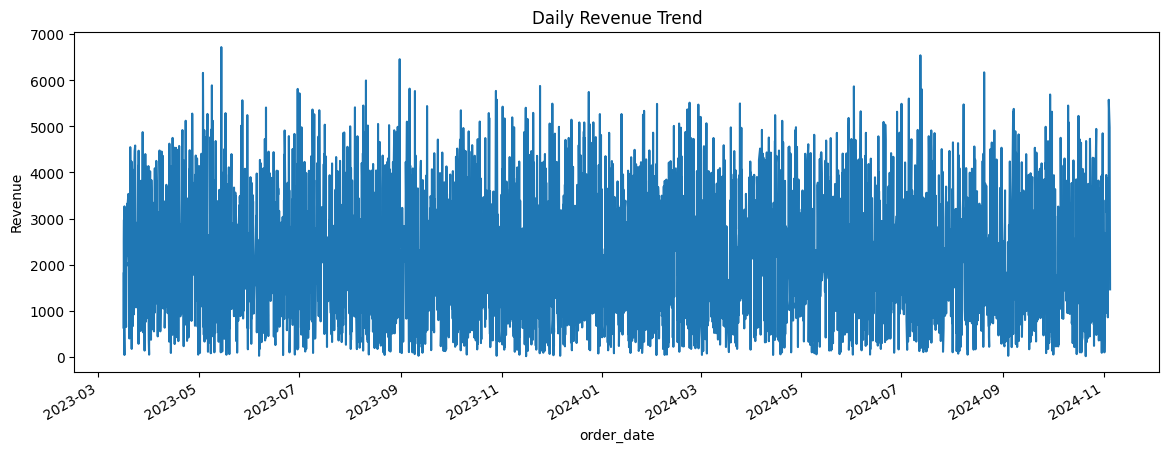

In [6]:
daily_sales = orders.groupby('order_date')['order_total'].sum()

daily_sales.plot(figsize=(14,5),title="Daily Revenue Trend")
plt.ylabel("Revenue")
plt.show()

Month
2023-08    623472.35
2023-12    615709.03
2023-05    608213.54
2023-10    578369.83
2024-05    574163.61
2024-07    573111.98
2023-09    571117.81
2023-11    567783.74
2023-07    567639.91
2024-01    560423.56
2023-04    554344.77
2024-08    546194.57
2024-02    545090.11
2024-03    543181.85
2024-06    539074.85
2024-04    538754.75
2024-10    537702.94
2024-09    518695.03
2023-06    505227.66
2023-03    272878.96
2024-11     68157.65
Freq: M, Name: order_total, dtype: float64


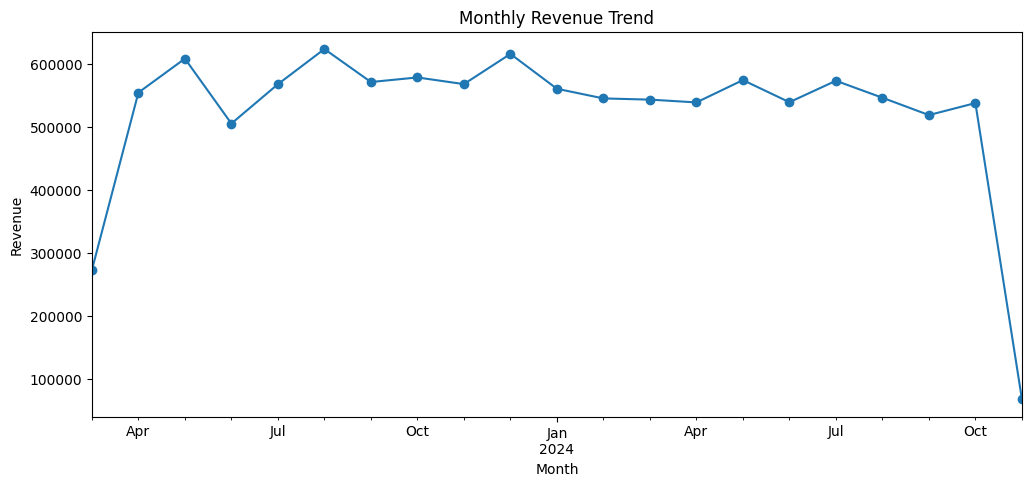

In [14]:
orders['Month'] = orders['order_date'].dt.to_period('M')
monthly_sales = orders.groupby('Month')['order_total'].sum()
print(monthly_sales.sort_values(ascending=False))
monthly_sales.plot(kind="line",marker="o",figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

### Business Question

How is revenue changing every month?

### Observation

Revenue steadily increased from March to May 2023 while it sees the peak in August 2023 and a dip is seen for 3 months.Then Secondary Peak is observed in December 2023. In 2024, May and July Months' Performance is good.

### Recommendation

Increase inventory during high-demand months.

### Payment Method Analysis

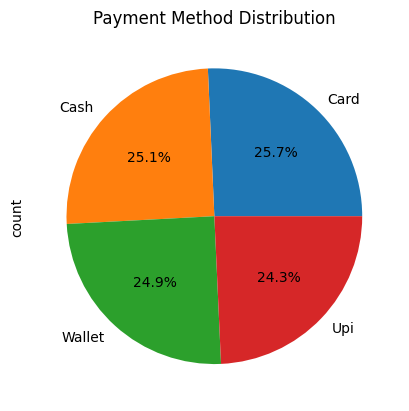

In [17]:
payment = orders['payment_method'].value_counts()

payment.plot(kind='pie',autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

### Business Question
Which payment method do customers prefer?

### Observation
Card contributes 25.7% of transactions.

### Recommendation
Offer cashback campaigns for Card users.

### Delivery Performance

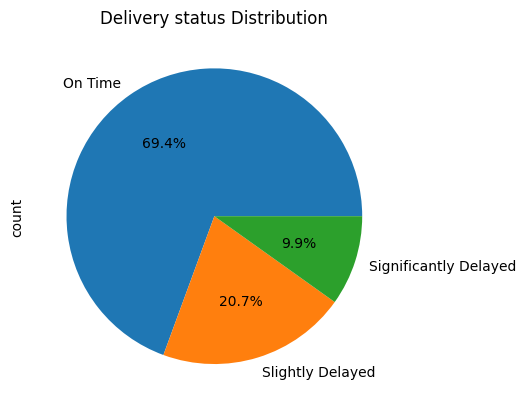

In [21]:
orders["delivery_status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Delivery status Distribution")
plt.show()

### Business Question
How efficient are deliveries?

### Observation
69.4% of orders are On-time Delivered.

### Recommendation
Allocate more Staffs to avoid Delay in Deliveries which is 30.6%.

### Order Size Analysis

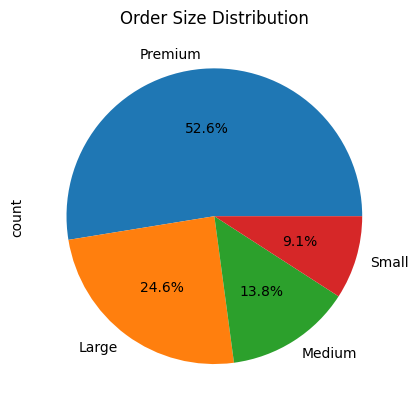

In [29]:
orders["Order_size"].value_counts().plot(kind="pie",autopct='%1.1f%%')
plt.title("Order Size Distribution")
plt.show()

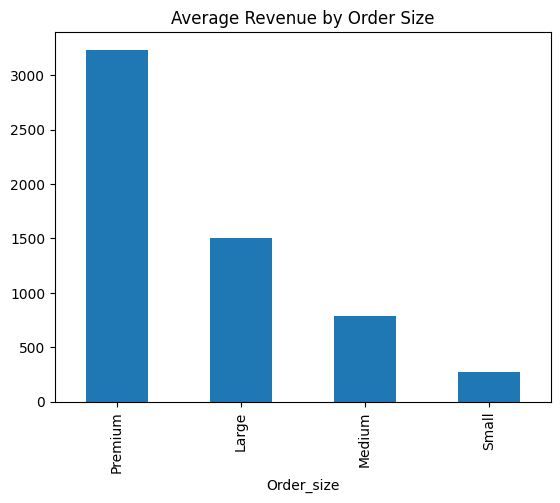

In [28]:
orders.groupby("Order_size")["order_total"].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Revenue by Order Size")
plt.show()

### Business Question
Which order category generates maximum revenue?

### Observation
Premium Order Category generates maximum revenue as they hold 52.6% in the whole orders distribution.

### Recommendation
Premium Order-specific Offers are recommended.

### Revenue by Customer Segment

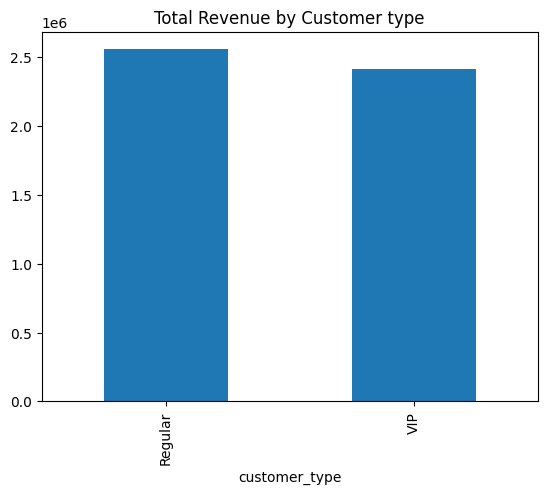

In [32]:
master_df.groupby("customer_type")["Revenue"].sum().plot(kind="bar")
plt.title("Total Revenue by Customer type")
plt.show()

In [33]:
master_df.groupby("customer_type")["Revenue"].sum()

customer_type
Regular    2558535.96
VIP        2413879.47
Name: Revenue, dtype: float64

### Business Question
Which customer type generates maximum revenue?

### Observation
Regular Customer Category generates maximum revenue.

### Recommendation
Customer type-specific Offers are recommended.

### Time-Based Analysis

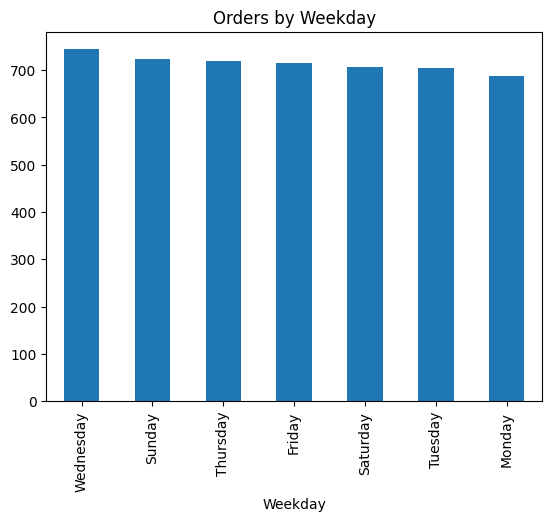

In [35]:
orders['Weekday'] = orders['order_date'].dt.day_name()

orders["Weekday"].value_counts().plot(kind="bar")
plt.title("Orders by Weekday")
plt.show()

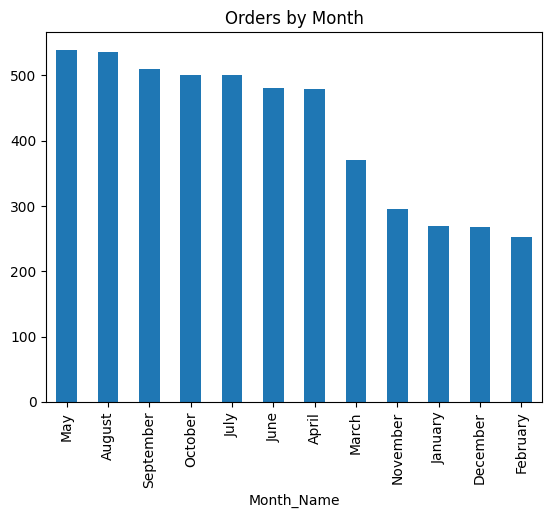

In [36]:
orders["Month_Name"] = orders["order_date"].dt.month_name()

orders["Month_Name"].value_counts().plot(kind="bar")
plt.title("Orders by Month")
plt.show()

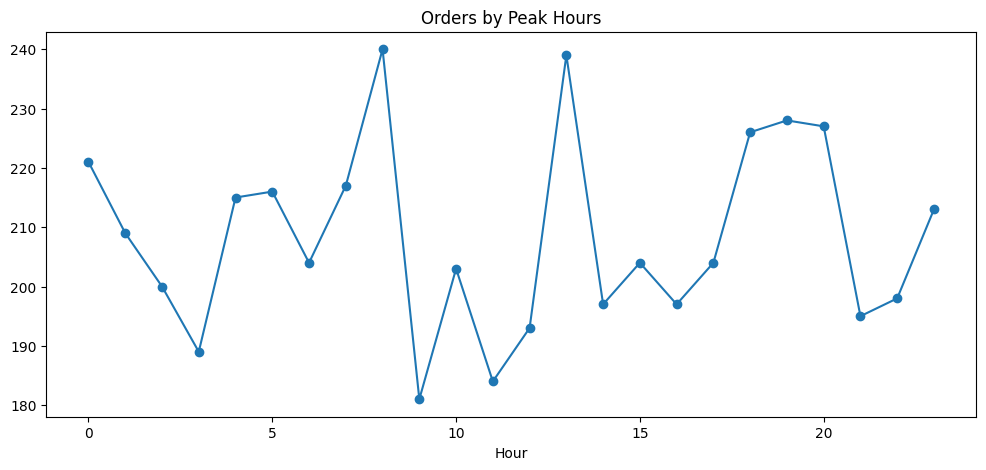

In [37]:
orders["Hour"] = pd.to_datetime(orders["order_date"]).dt.hour

orders.groupby("Hour")["order_id"].count().plot(kind='line',marker='o',figsize=(12,5))
plt.title("Orders by Peak Hours")
plt.show()

### Business Question
When did the highest no of orders placed? Give the result in Weekday, Month and hourly basis.

### Observation
Highest no of orders placed on Wednesday in Weekdays, May month in Months and morning 8 A.M. observed to be Peak hours. 

### Recommendation
Optimize staffing and inventory during peak order periods.

### Correlation Analysis

In [40]:
orders[["order_total","Delivery_Delay_Minutes","Late_Delivery_Flag"]].corr()

,order_total,Delivery_Delay_Minutes,Late_Delivery_Flag
order_total,1.000000,-0.002457,0.005307
Delivery_Delay_Minutes,-0.002457,1.000000,0.671580
Late_Delivery_Flag,0.005307,0.671580,1.000000


### Business Question
Do larger orders experience more delays? Does delay affect order value?

### Observation
Yes, There is a slight negative correlation between Orders and Delays and a slight correlation between Late Delivery and Orders. It has been observed that larger orders experience more delays slightly, not significantly.

### Recommendation
Optimize staffing and inventory during peak order periods and avoid Late deliveries.

### Outlier Analysis

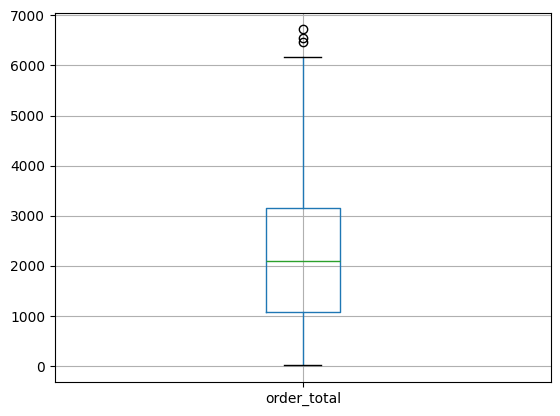

In [41]:
orders.boxplot(column="order_total")
plt.show()

In [42]:
print(orders['order_total'].mean())
print(orders['order_total'].max())

2201.8617
6721.46


### Business Question
Are there any Extremely high-value orders, Unusual spending behavior?

### Observation
Yes, There are Extremely high-value orders and Unusual spending behavior noticed.

### Business Impact

### Revenue Impact:
Increase expected revenue by focusing on high-performing order segments.

### Customer Impact:
Improve customer satisfaction by reducing late deliveries.

### Operational Impact:
Optimize staffing and inventory during peak order periods.